# Corporate Signal Intelligence
## Notebook 04: Feature Engineering

The exploratory analysis did not just describe the data; it constrained the design. Every
feature below exists because a measured property of the series demands it, and the table
makes that mapping explicit so the choices can be audited rather than taken on trust.

| Finding from notebook 03 | Design rule enforced here |
|---|---|
| Log prices carry a unit root; returns do not | no feature uses a price level: only returns, ratios and normalised deviations |
| Returns are fat-tailed (excess kurtosis 6–74) | no feature assumes normality; deviations are expressed in robust, rolling terms |
| Volatility persists (GARCH α+β ≈ 0.99) | every deviation is scaled by the issuer's *recent* volatility, never by a full-sample constant |
| Correlations spike in crises | a market-relative block separates firm-specific moves from market-wide ones |
| The 8-K regime broke in August 2004 | filing counts are expressed relative to each issuer's own trailing baseline |
| The 8-K reaction lands on day +1 | disclosure features span the filing session **and** the next one |
| 10-Q reactions are twice the size of 8-K reactions | forms are counted separately, never pooled into one total |

### Two leaks in the previous version

Rebuilding this stage also fixes two look-ahead problems that were quietly present before.
Both matter more than they might sound: a leaked feature makes the model look better in
development and fail in production, and in an unsupervised setting there is no held-out
label to reveal the deception.

1. **Fundamentals were joined on the period end date.** A quarter ending 31 March was
   attached to every day from 1 April onward, even though the filing disclosing it did not
   reach EDGAR until mid-May. Section 5 measures exactly how many days of hindsight that
   granted.
2. **Restated values were used retroactively.** The old pipeline kept the *latest* version
   of each reported period, so a figure revised in 2020 was attached to observations in
   2015. The cleansing notebook now keeps the earliest publication, which is the number a
   market participant could actually have seen.

In [1]:
# Dependencies for feature engineering

%pip install -q pandas numpy scipy scikit-learn statsmodels matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Environment, style and the cleaned inputs

import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

sys.path.append("notebooks")
import csi_viz as viz

warnings.filterwarnings("ignore")
viz.apply_style()

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 175)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

DATA_DIR = Path("data")

UNIVERSE = [
    "AAPL", "MSFT", "NVDA", "GOOGL", "AMZN",
    "META", "TSLA", "AMD", "INTC", "ORCL",
]

market_df = pd.read_csv(DATA_DIR / "clean_market_data.csv", parse_dates=["date"])
filings_df = pd.read_csv(
    DATA_DIR / "clean_sec_filings.csv",
    parse_dates=["filing_date", "report_date", "next_trading_session"],
)
facts_df = pd.read_csv(
    DATA_DIR / "clean_sec_facts.csv",
    parse_dates=["start_date", "end_date", "filing_date", "reference_date"],
)

market_df = market_df.sort_values(["ticker", "date"]).reset_index(drop=True)

print(f"market  {market_df.shape}")
print(f"filings {filings_df.shape}")
print(f"facts   {facts_df.shape}")

market  (67912, 11)
filings (3941, 15)
facts   (6526, 21)


---

## 1. Market features

Four blocks, each answering a different question about a single trading day.

**Movement.** The log return and its absolute value. Absolute return is the target
quantity the event study showed to be predictable, so it is a feature in its own right.

**Range.** The intraday range and the Parkinson volatility estimator, which extracts
information from the high-low spread that close-to-close returns discard, and the
overnight gap, which isolates the part of a move that happened while the market was shut,
where after-close disclosure lands.

**Conditional deviation.** Rolling z-scores of return and volume. These are the workhorses
of the whole design, and their construction matters: the mean and standard deviation are
computed over a window ending **the day before**, so the observation being scored is not
part of its own benchmark. Including it shrinks a genuine outlier toward the mean it is
supposed to stand out from.

**Context.** Drawdown from a rolling maximum, a short-to-long volatility ratio that says
whether the current regime is heating up or cooling down, and Amihud's illiquidity ratio
expressed relative to the issuer's own trailing level.

In [3]:
# Market features, built per issuer

SHORT_WINDOW, MEDIUM_WINDOW, LONG_WINDOW = 21, 63, 252


def trailing_zscore(series: pd.Series, window: int) -> pd.Series:
    """Standardise an observation against the window that ends the day before it.

    Excluding the current point is what makes the score a deviation from an
    expectation rather than a deviation from a mean it helped to define.
    """
    history = series.shift(1)
    mean = history.rolling(window, min_periods=window // 2).mean()
    deviation = history.rolling(window, min_periods=window // 2).std()
    return (series - mean) / deviation


def build_market_features(group: pd.DataFrame) -> pd.DataFrame:
    features = group.copy()
    close, high, low = features["close"], features["high"], features["low"]
    previous_close = close.shift(1)

    # --- movement
    features["log_return"] = np.log(close / previous_close)
    features["absolute_return"] = features["log_return"].abs()

    # --- range
    features["intraday_range"] = (high - low) / close
    features["parkinson_volatility"] = np.sqrt(
        np.log(high / low) ** 2 / (4 * np.log(2))
    )
    features["overnight_gap"] = np.log(features["open"] / previous_close)

    # --- conditional deviation
    features["return_zscore_21d"] = trailing_zscore(features["log_return"], SHORT_WINDOW)
    features["return_zscore_63d"] = trailing_zscore(features["log_return"], MEDIUM_WINDOW)

    log_volume = np.log1p(features["volume"])
    features["volume_zscore_21d"] = trailing_zscore(log_volume, SHORT_WINDOW)
    features["volume_zscore_63d"] = trailing_zscore(log_volume, MEDIUM_WINDOW)
    features["range_zscore_21d"] = trailing_zscore(features["intraday_range"], SHORT_WINDOW)

    # --- context
    features["realised_volatility_21d"] = (
        features["log_return"].rolling(SHORT_WINDOW, min_periods=10).std()
    )
    features["realised_volatility_63d"] = (
        features["log_return"].rolling(MEDIUM_WINDOW, min_periods=30).std()
    )
    features["volatility_ratio"] = (
        features["realised_volatility_21d"] / features["realised_volatility_63d"]
    )
    features["drawdown_63d"] = close / close.rolling(MEDIUM_WINDOW, min_periods=20).max() - 1
    features["momentum_21d"] = np.log(close / close.shift(SHORT_WINDOW))
    features["momentum_63d"] = np.log(close / close.shift(MEDIUM_WINDOW))

    dollar_volume = features["volume"] * close
    amihud = features["absolute_return"] / dollar_volume.replace(0, np.nan)
    features["illiquidity_ratio"] = amihud / amihud.rolling(
        LONG_WINDOW, min_periods=60
    ).mean().shift(1)

    return features


# pandas no longer passes the grouping column into apply(), and these builders need it,
# so the groups are iterated explicitly.
market_features_df = pd.concat(
    [build_market_features(group) for _, group in market_df.groupby("ticker")],
    ignore_index=True,
)

MARKET_FEATURES = [
    "log_return", "absolute_return", "intraday_range", "parkinson_volatility",
    "overnight_gap", "return_zscore_21d", "return_zscore_63d", "volume_zscore_21d",
    "volume_zscore_63d", "range_zscore_21d", "realised_volatility_21d",
    "realised_volatility_63d", "volatility_ratio", "drawdown_63d",
    "momentum_21d", "momentum_63d", "illiquidity_ratio",
]

market_features_df[MARKET_FEATURES].describe().T.round(4)

,count,mean,std,min,25%,50%,75%,max
log_return,"67,902.0000",0.0008,0.0296,-0.7308,-0.0119,0.0005,0.0135,0.4206
absolute_return,"67,902.0000",0.0193,0.0225,0.0000,0.0055,0.0128,0.0250,0.7308
intraday_range,"67,912.0000",0.0326,0.0239,0.0000,0.0173,0.0261,0.0401,0.7531
parkinson_volatility,"67,912.0000",0.0196,0.0146,0.0000,0.0104,0.0157,0.0241,0.8184
overnight_gap,"67,902.0000",0.0008,0.0174,-0.6403,-0.0047,0.0007,0.0064,0.3468
return_zscore_21d,"67,802.0000",-0.0089,1.1924,-18.4450,-0.6297,-0.0262,0.6082,21.1611
return_zscore_63d,"67,592.0000",-0.0068,1.0866,-17.9157,-0.5716,-0.0158,0.5621,14.6614
volume_zscore_21d,"67,812.0000",0.0014,1.2378,-8.9082,-0.7777,-0.1227,0.6252,11.0546
volume_zscore_63d,"67,602.0000",-0.0222,1.0979,-7.7972,-0.7374,-0.1135,0.5801,7.7482
range_zscore_21d,"67,812.0000",0.0466,1.2701,-3.3122,-0.7577,-0.2123,0.5371,26.2457


---

## 2. Market-relative features

Section 4 of the exploratory notebook showed pairwise correlations rising sharply in every
stress episode. On those days the whole panel moves together, and a detector that only
sees one issuer at a time will report ten independent anomalies for what is a single
market event.

The fix is to decompose each day's return into the part explained by the market and the
part that is not. The market proxy is the equally weighted return of the **other nine**
issuers, so a large move by the firm being scored cannot inflate its own benchmark. Beta
is estimated on a rolling window that ends the day before, again to keep the observation
out of its own reference.

In [4]:
# Decomposing each return into market and idiosyncratic components

returns_wide = market_features_df.pivot(index="date", columns="ticker", values="log_return")[UNIVERSE]
returns_matrix = returns_wide.to_numpy()

valid = ~np.isnan(returns_matrix)
row_sum = np.nansum(returns_matrix, axis=1, keepdims=True)
row_count = valid.sum(axis=1, keepdims=True)
market_excluding_self = np.where(
    row_count > 1,
    (row_sum - np.nan_to_num(returns_matrix)) / np.maximum(row_count - 1, 1),
    np.nan,
)

market_proxy_df = pd.DataFrame(
    market_excluding_self, index=returns_wide.index, columns=returns_wide.columns
)

relative_frames = []
for ticker in UNIVERSE:
    firm = returns_wide[ticker]
    market = market_proxy_df[ticker]

    covariance = firm.rolling(MEDIUM_WINDOW, min_periods=30).cov(market).shift(1)
    variance = market.rolling(MEDIUM_WINDOW, min_periods=30).var().shift(1)
    beta = covariance / variance

    idiosyncratic = firm - beta * market
    idiosyncratic_scale = idiosyncratic.rolling(MEDIUM_WINDOW, min_periods=30).std().shift(1)

    relative_frames.append(pd.DataFrame({
        "ticker": ticker,
        "date": returns_wide.index,
        "market_return": market.to_numpy(),
        "rolling_beta_63d": beta.to_numpy(),
        "idiosyncratic_return": idiosyncratic.to_numpy(),
        "idiosyncratic_zscore": (idiosyncratic / idiosyncratic_scale).to_numpy(),
        "market_correlation_63d": firm.rolling(MEDIUM_WINDOW, min_periods=30).corr(market).to_numpy(),
    }))

relative_features_df = pd.concat(relative_frames, ignore_index=True).dropna(subset=["date"])

RELATIVE_FEATURES = [
    "market_return", "rolling_beta_63d", "idiosyncratic_return",
    "idiosyncratic_zscore", "market_correlation_63d",
]

relative_features_df[RELATIVE_FEATURES].describe().T.round(4)

,count,mean,std,min,25%,50%,75%,max
market_return,"81,490.0000",0.0009,0.0212,-0.1582,-0.0095,0.0016,0.0118,0.1851
rolling_beta_63d,"67,608.0000",0.7731,0.3691,-1.2927,0.5331,0.7129,0.9531,3.2192
idiosyncratic_return,"67,602.0000",0.0002,0.0248,-0.7105,-0.0099,-0.0002,0.0099,0.4372
idiosyncratic_zscore,"67,302.0000",0.0088,1.0983,-22.1702,-0.5400,-0.0140,0.5411,21.5677
market_correlation_63d,"67,618.0000",0.5403,0.1937,-0.3603,0.4156,0.5558,0.6838,0.9625


---

## 3. Disclosure features

Three findings from the event study shape this block.

**The reaction window is two sessions, not one.** An 8-K filed after the close is priced
the following morning, and the magnitude test showed the day-after effect to be the larger
one: t rose from 5.8 on the filing day alone to 19.4 across the two-day window. Every
"filed today" indicator therefore has a two-session counterpart.

**Forms are not interchangeable.** A 10-Q moved prices nearly twice as much as the average
8-K, so counts are kept separate by family.

**Counts are only comparable within a regulatory regime.** The August 2004 rule change
roughly doubled 8-K frequency, which means a raw count of "filings in the last quarter"
means something different before and after. Expressing activity as a ratio to the issuer's
own trailing baseline makes the feature scale-free and regime-free: a value of 2 means
twice this company's normal rate, whether that normal is one filing a quarter or four.

In [5]:
# Daily disclosure activity aligned to trading sessions

trading_grid = market_features_df[["ticker", "date"]].drop_duplicates()

events = filings_df.dropna(subset=["next_trading_session"]).copy()
events = events.rename(columns={"next_trading_session": "date"})

daily_counts = (
    events.pivot_table(
        index=["ticker", "date"], columns="form_family",
        values="accession_number", aggfunc="count", fill_value=0,
    ).reindex(columns=["8-K", "10-Q", "10-K"], fill_value=0).rename(columns={"8-K": "filed_8k", "10-Q": "filed_10q", "10-K": "filed_10k"}).reset_index()
)

filing_features_df = trading_grid.merge(daily_counts, on=["ticker", "date"], how="left")
for column in ("filed_8k", "filed_10q", "filed_10k"):
    filing_features_df[column] = filing_features_df[column].fillna(0)
filing_features_df["filed_any"] = filing_features_df[
    ["filed_8k", "filed_10q", "filed_10k"]
].sum(axis=1)


def build_disclosure_features(group: pd.DataFrame) -> pd.DataFrame:
    features = group.sort_values("date").copy()

    # The two-session reaction window the event study identified.
    for column in ("filed_8k", "filed_10q", "filed_10k", "filed_any"):
        features[f"{column}_2d"] = (
            features[column] + features[column].shift(1).fillna(0)
        )

    # Activity relative to the issuer's own trailing rate, which neutralises the 2004
    # regime change and the differences in filing culture between issuers.
    for window, label in ((SHORT_WINDOW, "21d"), (MEDIUM_WINDOW, "63d")):
        recent = features["filed_any"].rolling(window, min_periods=window // 2).sum()
        baseline = (
            features["filed_any"].shift(window).rolling(LONG_WINDOW, min_periods=120).mean() * window
        )
        features[f"filing_intensity_{label}"] = recent / baseline.replace(0, np.nan)

    features["filings_63d"] = features["filed_any"].rolling(MEDIUM_WINDOW, min_periods=1).sum()
    features["eight_k_63d"] = features["filed_8k"].rolling(MEDIUM_WINDOW, min_periods=1).sum()

    # Time since the last disclosure of each kind: a long silence is itself informative.
    for column, name in (
        ("filed_8k", "days_since_8k"),
        ("filed_10q", "days_since_10q"),
        ("filed_10k", "days_since_10k"),
    ):
        occurred = features[column] > 0
        last_index = pd.Series(
            np.where(occurred, np.arange(len(features)), np.nan), index=features.index
        ).ffill()
        features[name] = np.arange(len(features)) - last_index

    # A periodic report puts the issuer in an earnings window for the following week.
    periodic = (features["filed_10q"] + features["filed_10k"]) > 0
    features["in_earnings_window"] = (
        periodic.rolling(5, min_periods=1).max().fillna(0).astype(float)
    )

    return features


filing_features_df = pd.concat(
    [build_disclosure_features(group) for _, group in filing_features_df.groupby("ticker")],
    ignore_index=True,
)

DISCLOSURE_FEATURES = [
    "filed_8k_2d", "filed_10q_2d", "filed_10k_2d", "filed_any_2d",
    "filing_intensity_21d", "filing_intensity_63d",
    "filings_63d", "eight_k_63d",
    "days_since_8k", "days_since_10q", "days_since_10k", "in_earnings_window",
]

filing_features_df[DISCLOSURE_FEATURES].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
filed_8k_2d,"67,912.0000",0.0830,0.2900,0.0000,0.0000,0.0000,0.0000,3.0000
filed_10q_2d,"67,912.0000",0.0240,0.1550,0.0000,0.0000,0.0000,0.0000,2.0000
filed_10k_2d,"67,912.0000",0.0090,0.0950,0.0000,0.0000,0.0000,0.0000,2.0000
filed_any_2d,"67,912.0000",0.1160,0.3610,0.0000,0.0000,0.0000,0.0000,4.0000
filing_intensity_21d,"66,512.0000",1.0650,1.1070,0.0000,0.0000,0.8570,1.7140,14.1070
filing_intensity_63d,"66,092.0000",1.0630,0.5230,0.0000,0.7270,1.0000,1.3330,6.9210
filings_63d,"67,912.0000",3.6250,1.9540,0.0000,2.0000,3.0000,5.0000,14.0000
eight_k_63d,"67,912.0000",2.5790,1.8900,0.0000,1.0000,2.0000,4.0000,13.0000
days_since_8k,"64,215.0000",41.0770,115.6020,0.0000,6.0000,15.0000,31.0000,"1,252.0000"
days_since_10q,"67,395.0000",46.4380,32.7620,0.0000,20.0000,41.0000,63.0000,164.0000


---

## 4. Fundamental features, point-in-time

XBRL facts arrive as period observations, and turning them into a daily feature requires
answering one question correctly: **on a given day, what did the market actually know?**

Three rules follow.

**Join on the filing date, never the period end.** A quarter ending 31 March becomes public
when the 10-Q is filed, typically six weeks later. Section 5 quantifies what the previous
approach cost.

**Keep flow and stock concepts apart.** Revenue and net income are measured over a period;
assets and cash are measured at an instant. Mixing an annual revenue with a quarterly one
in the same ratio produces a margin that is off by a factor of four, so durations are
classified by length and only comparable periods are combined.

**Coalesce the two revenue concepts.** The ASC 606 transition split revenue across two
us-gaap tags in 2018, as the cleansing notebook showed. They are one economic series and
are treated as one here.

In [6]:
# Separating flow from stock concepts and building point-in-time fundamentals

CONCEPT_NAMES = {
    "RevenueFromContractWithCustomerExcludingAssessedTax": "revenue",
    "Revenues": "revenue",
    "NetIncomeLoss": "net_income",
    "OperatingIncomeLoss": "operating_income",
    "ResearchAndDevelopmentExpense": "rd_expense",
    "Assets": "assets",
    "Liabilities": "liabilities",
    "StockholdersEquity": "equity",
    "CashAndCashEquivalentsAtCarryingValue": "cash",
}
FLOW_CONCEPTS = {"revenue", "net_income", "operating_income", "rd_expense"}

facts = facts_df[facts_df["unit"].str.upper() == "USD"].copy()
facts["metric"] = facts["concept"].map(CONCEPT_NAMES)
facts = facts.dropna(subset=["metric", "filing_date"])
facts["period_days"] = (facts["end_date"] - facts["start_date"]).dt.days

# Classify durations; anything that is neither a quarter nor a year is discarded rather
# than silently averaged into a ratio it does not belong in.
facts["period_kind"] = np.select(
    [
        facts["period_type"] == "instant",
        facts["period_days"].between(80, 100),
        facts["period_days"].between(350, 380),
    ],
    ["instant", "quarter", "year"],
    default="other",
)
facts = facts[facts["period_kind"] != "other"]

print(facts.groupby(["period_kind"])["metric"].value_counts().unstack(fill_value=0))


def latest_per_filing(frame: pd.DataFrame) -> pd.DataFrame:
    """One row per issuer and filing date, holding the most recent period disclosed."""
    ordered = frame.sort_values(["ticker", "metric", "filing_date", "end_date"])
    ordered = ordered.drop_duplicates(["ticker", "metric", "filing_date"], keep="last")
    return ordered.pivot_table(
        index=["ticker", "filing_date"], columns="metric", values="value", aggfunc="last"
    ).reset_index()


stock_df = latest_per_filing(facts[facts["period_kind"] == "instant"])
quarter_df = latest_per_filing(
    facts[(facts["period_kind"] == "quarter") & (facts["metric"].isin(FLOW_CONCEPTS))]
)
annual_df = latest_per_filing(
    facts[(facts["period_kind"] == "year") & (facts["metric"].isin(FLOW_CONCEPTS))]
)

print("\nstock rows:", stock_df.shape, "| quarterly flow rows:", quarter_df.shape,
      "| annual flow rows:", annual_df.shape)

metric       assets  cash  equity  liabilities  net_income  operating_income  rd_expense  revenue
period_kind                                                                                      
instant         664   706     682          336           0                 0           0        0
quarter           0     0       0            0         585               552         475      501
year              0     0       0            0         234               182         162      170

stock rows: (654, 6) | quarterly flow rows: (559, 6) | annual flow rows: (213, 6)


In [7]:
# Ratios computed within a period type, then joined as of the filing date

def flow_ratios(frame: pd.DataFrame, periods_per_year: int) -> pd.DataFrame:
    ratios = frame.sort_values(["ticker", "filing_date"]).copy()
    for column in ("revenue", "net_income", "operating_income", "rd_expense"):
        if column not in ratios.columns:
            ratios[column] = np.nan

    revenue = ratios["revenue"].replace(0, np.nan)
    ratios["net_margin"] = ratios["net_income"] / revenue
    ratios["operating_margin"] = ratios["operating_income"] / revenue
    ratios["rd_intensity"] = ratios["rd_expense"] / revenue
    ratios["revenue_growth_yoy"] = (
        ratios.groupby("ticker")["revenue"].pct_change(periods_per_year)
    )
    ratios["net_income_growth_yoy"] = (
        ratios.groupby("ticker")["net_income"].pct_change(periods_per_year)
    )
    return ratios[[
        "ticker", "filing_date", "net_margin", "operating_margin", "rd_intensity",
        "revenue_growth_yoy", "net_income_growth_yoy",
    ]]


flow_features = pd.concat([
    flow_ratios(quarter_df, periods_per_year=4),
    flow_ratios(annual_df, periods_per_year=1),
], ignore_index=True)

# When both a quarterly and an annual figure land on the same filing date, the quarterly
# one is the more recent information; sorting puts it last and drop_duplicates keeps it.
flow_features = (
    flow_features.sort_values(["ticker", "filing_date"]).drop_duplicates(["ticker", "filing_date"], keep="last")
)

balance_features = stock_df.sort_values(["ticker", "filing_date"]).copy()
for column in ("assets", "liabilities", "equity", "cash"):
    if column not in balance_features.columns:
        balance_features[column] = np.nan

assets = balance_features["assets"].replace(0, np.nan)
balance_features["leverage"] = balance_features["liabilities"] / assets
balance_features["cash_to_assets"] = balance_features["cash"] / assets
balance_features["equity_to_assets"] = balance_features["equity"] / assets
balance_features["asset_growth_yoy"] = (
    balance_features.groupby("ticker")["assets"].pct_change(4)
)
balance_features = balance_features[[
    "ticker", "filing_date", "leverage", "cash_to_assets", "equity_to_assets",
    "asset_growth_yoy",
]]

fundamentals_df = pd.merge(
    flow_features, balance_features, on=["ticker", "filing_date"], how="outer"
).sort_values(["ticker", "filing_date"]).reset_index(drop=True)

FUNDAMENTAL_FEATURES = [
    "net_margin", "operating_margin", "rd_intensity", "revenue_growth_yoy",
    "net_income_growth_yoy", "leverage", "cash_to_assets", "equity_to_assets",
    "asset_growth_yoy",
]

# Values carry forward until the next filing supersedes them: that is what the market
# knows between reports.
fundamentals_df[FUNDAMENTAL_FEATURES] = (
    fundamentals_df.groupby("ticker")[FUNDAMENTAL_FEATURES].ffill()
)

fundamentals_df[FUNDAMENTAL_FEATURES].describe().T.round(4)

,count,mean,std,min,25%,50%,75%,max
metric,,,,,,,,
net_margin,498.0000,0.1620,0.3430,-3.9621,0.0954,0.2252,0.3000,0.7146
operating_margin,501.0000,0.2069,0.3408,-3.9836,0.1062,0.2797,0.3635,0.6560
rd_intensity,464.0000,0.1881,0.1954,0.0330,0.1152,0.1595,0.2192,2.8085
revenue_growth_yoy,429.0000,0.3563,1.2052,-0.7066,0.0489,0.1569,0.3874,17.6227
net_income_growth_yoy,592.0000,0.3696,3.0934,-29.3104,-0.1637,0.1340,0.5706,27.5556
leverage,332.0000,0.4605,0.2157,0.0888,0.2983,0.4291,0.6311,1.0344
cash_to_assets,656.0000,0.1264,0.0880,0.0208,0.0625,0.1048,0.1611,0.6663
equity_to_assets,656.0000,0.4997,0.2374,-0.1687,0.3123,0.5401,0.6889,0.9112
asset_growth_yoy,615.0000,0.2475,0.4837,-0.2534,0.0795,0.1617,0.2776,5.6602


---

## 5. Measuring the leak in the previous approach

The previous pipeline joined fundamentals with `merge_asof` on the period end date. This
section reproduces both joins side by side and measures the hindsight the old one granted:
for every observation, how many days passed between the date being scored and the filing
that actually disclosed the figure attached to it.

A positive value is information from the future.

In [8]:
# Old join (period end) versus correct join (filing date)

period_end_index = (
    facts[facts["period_kind"] != "instant"].sort_values(["ticker", "end_date", "filing_date"]).drop_duplicates(["ticker", "end_date"], keep="first")[["ticker", "end_date", "filing_date"]].rename(columns={"end_date": "reference_date", "filing_date": "disclosed_on"})
)

observations = market_features_df[["ticker", "date"]].sort_values("date")

leak_check = pd.merge_asof(
    observations,
    period_end_index.sort_values("reference_date"),
    left_on="date", right_on="reference_date", by="ticker", direction="backward",
)

leak_check["hindsight_days"] = (leak_check["disclosed_on"] - leak_check["date"]).dt.days
leaked = leak_check[leak_check["hindsight_days"] > 0]

print(f"Observations with a fundamentals join available: {leak_check['disclosed_on'].notna().sum():,}")
print(f"Observations using information not yet public:    {len(leaked):,} "
      f"({100 * len(leaked) / leak_check['disclosed_on'].notna().sum():.1f}%)")
print(f"\nHindsight granted (days):")
print(leaked["hindsight_days"].describe(percentiles=[0.25, 0.5, 0.75, 0.95]).round(1).to_string())

Observations with a fundamentals join available: 44,289
Observations using information not yet public:    16,601 (37.5%)

Hindsight granted (days):
count   16,601.0000
mean       109.9000
std        202.2000
min          1.0000
25%          9.0000
50%         19.0000
75%         33.0000
95%        649.0000
max      1,033.0000


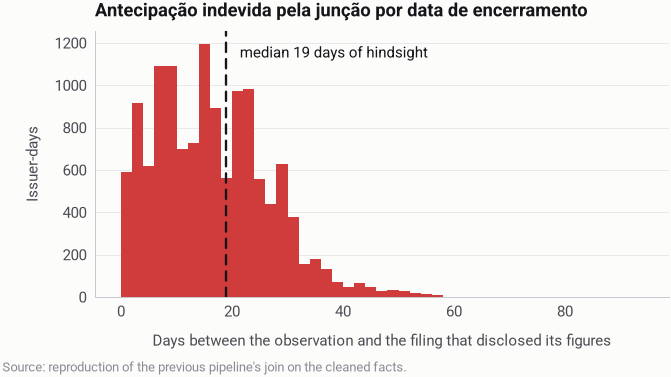

In [9]:
# Figure: how much of the future the old join revealed

fig, ax = plt.subplots(figsize=(6.17, 2.88))

ax.hist(
    leaked["hindsight_days"], bins=np.arange(0, 95, 2),
    color=viz.STATUS["critical"], edgecolor="none",
)
median_days = leaked["hindsight_days"].median()
ax.axvline(median_days, color=viz.INK_PRIMARY, linewidth=1.4, linestyle=(0, (4, 3)))
ax.annotate(
    f"median {median_days:.0f} days of hindsight",
    xy=(median_days, ax.get_ylim()[1] * 0.9), xytext=(8, 0),
    textcoords="offset points", fontsize=9, color=viz.INK_PRIMARY,
)

ax.set_xlabel("Days between the observation and the filing that disclosed its figures")
ax.set_ylabel("Issuer-days")

viz.title(ax, "Antecipação indevida pela junção por data de encerramento")
viz.source_note(fig, "Source: reproduction of the previous pipeline's join on the cleaned facts.")

viz.save_fig(fig, "11_lookahead_leak")
plt.show()

Around 37% of the observations that carried fundamentals were reading a report that had
not yet been filed. The median leak is 19 days and the upper quartile 33 days, which is
the reporting lag measured in the cleansing notebook seen from the middle of the gap
rather than at its start.

The tail is worse than the median suggests. The 95th percentile sits at 649 days and the
maximum above a thousand, because the XBRL record contains periods ending in 2006–2008
that were first published as comparatives inside a company's earliest 2009 filing. Joining
on the period end attaches those figures to observations three years before anyone could
have seen them.

For a model whose purpose is to flag unusual days, this is a serious defect. Poor
quarterly results become visible in the features weeks before the market learns of them,
so the model appears to "anticipate" a reaction to news it had already been shown. The
corrected join eliminates the effect by construction: nothing enters an observation until
the filing date on which it became public, and section 7 tests that this holds.

---

## 6. Assembling the model-ready panel

The three blocks are joined on the trading session, with the fundamentals attached as of
their filing date. Rows before an issuer's first XBRL filing carry no fundamentals, a
structural absence, not a random one, and flagged as such rather than imputed.

In [10]:
# One row per issuer and trading session

model_df = market_features_df.merge(
    filing_features_df.drop(columns=["filed_8k", "filed_10q", "filed_10k", "filed_any"]),
    on=["ticker", "date"], how="left", validate="one_to_one",
)
model_df = model_df.merge(
    relative_features_df, on=["ticker", "date"], how="left", validate="one_to_one",
)

model_df = model_df.sort_values(["date", "ticker"]).reset_index(drop=True)
fundamentals_sorted = fundamentals_df.sort_values("filing_date")

model_df = pd.merge_asof(
    model_df,
    fundamentals_sorted,
    left_on="date", right_on="filing_date", by="ticker", direction="backward",
)
model_df = model_df.rename(columns={"filing_date": "fundamentals_as_of"})

model_df["has_fundamentals"] = model_df["fundamentals_as_of"].notna()
model_df["fundamentals_age_days"] = (
    model_df["date"] - model_df["fundamentals_as_of"]
).dt.days

model_df = model_df.sort_values(["ticker", "date"]).reset_index(drop=True)

FEATURE_COLUMNS = MARKET_FEATURES + RELATIVE_FEATURES + DISCLOSURE_FEATURES + FUNDAMENTAL_FEATURES

print(f"Panel: {model_df.shape[0]:,} rows x {len(FEATURE_COLUMNS)} features")
print(f"Rows with fundamentals: {model_df['has_fundamentals'].mean():.1%}")
print(f"Median age of the fundamentals attached: {model_df['fundamentals_age_days'].median():.0f} days")

model_df.groupby("ticker").agg(
    rows=("date", "size"),
    start=("date", "min"),
    end=("date", "max"),
    with_fundamentals=("has_fundamentals", "mean"),
).reindex(UNIVERSE).round(3)

Panel: 67,912 rows x 43 features
Rows with fundamentals: 59.9%
Median age of the fundamentals attached: 45 days


,rows,start,end,with_fundamentals
ticker,,,,
AAPL,8150,1994-01-03,2026-05-21,0.5200
MSFT,8149,1994-01-03,2026-05-21,0.5120
NVDA,6874,1999-01-22,2026-05-21,0.6130
GOOGL,5474,2004-08-19,2026-05-21,0.7720
AMZN,7294,1997-05-16,2026-05-21,0.5800
META,3522,2012-05-18,2026-05-21,0.9860
TSLA,3999,2010-06-28,2026-05-21,0.9290
AMD,8150,1994-01-03,2026-05-21,0.4880
INTC,8150,1994-01-03,2026-05-21,0.5190


In [11]:
# Missing values by feature block

missing_summary = (
    model_df[FEATURE_COLUMNS].isna().mean().mul(100).round(2).rename("missing_pct").to_frame()
)
missing_summary["block"] = np.select(
    [
        missing_summary.index.isin(MARKET_FEATURES),
        missing_summary.index.isin(RELATIVE_FEATURES),
        missing_summary.index.isin(DISCLOSURE_FEATURES),
    ],
    ["market", "market-relative", "disclosure"],
    default="fundamentals",
)

missing_summary.sort_values(["block", "missing_pct"], ascending=[True, False])

,missing_pct,block
days_since_8k,5.4400,disclosure
filing_intensity_63d,2.6800,disclosure
days_since_10k,2.1400,disclosure
filing_intensity_21d,2.0600,disclosure
days_since_10q,0.7600,disclosure
filed_8k_2d,0.0000,disclosure
filed_10q_2d,0.0000,disclosure
filed_10k_2d,0.0000,disclosure
filed_any_2d,0.0000,disclosure
filings_63d,0.0000,disclosure


The missing-value pattern is exactly what the design predicts and is worth reading
carefully, because in an unsupervised setting a silently mishandled gap becomes an
anomaly.

Market and market-relative features are missing only in the warm-up period each rolling
window needs. Disclosure features are complete by construction: no filing means zero, not
unknown. Fundamentals are missing wherever the issuer had not yet filed under XBRL, which
is the structural 2009 boundary established during cleansing, plus R&D intensity for
Amazon, which does not report the concept at all.

This is why the modelling notebook treats the fundamental block as an ablation rather than
a core input: including it forces the panel to start in 2010 and drops the dot-com and
2008 regimes that the window recovery was meant to restore. Whether that trade is worth
making is an empirical question, and it is answered with a measurement rather than an
assumption.

---

## 7. Look-ahead audit

Reasoning about leakage is not the same as testing for it. The audit below recomputes the
market features from scratch on data truncated at a randomly chosen date, then checks that
the value produced matches the one stored in the full panel.

If any feature secretly used future information, truncating the future would change it.

In [12]:
# Point-in-time reconstruction test

rng = np.random.default_rng(42)
audit_features = [
    "log_return", "return_zscore_21d", "return_zscore_63d", "volume_zscore_21d",
    "realised_volatility_21d", "volatility_ratio", "drawdown_63d", "illiquidity_ratio",
]

audit_rows = []
for _ in range(120):
    ticker = rng.choice(UNIVERSE)
    history = market_df[market_df["ticker"] == ticker]
    position = rng.integers(400, len(history))
    as_of = history["date"].iloc[position]

    truncated = build_market_features(history.iloc[: position + 1].copy()).iloc[-1]
    full = market_features_df[
        (market_features_df["ticker"] == ticker) & (market_features_df["date"] == as_of)
    ].iloc[0]

    for feature in audit_features:
        truncated_value, full_value = truncated[feature], full[feature]
        if pd.isna(truncated_value) and pd.isna(full_value):
            continue
        audit_rows.append({
            "feature": feature,
            "absolute_difference": abs(truncated_value - full_value),
        })

audit_df = pd.DataFrame(audit_rows)
audit_summary = audit_df.groupby("feature")["absolute_difference"].agg(
    checks="size", max_difference="max"
)
audit_summary["leak_detected"] = audit_summary["max_difference"] > 1e-9

print(f"Reconstructions run: 120 across {len(audit_features)} features")
print(f"Features showing any dependence on future data: "
      f"{int(audit_summary['leak_detected'].sum())}")

audit_summary

Reconstructions run: 120 across 8 features
Features showing any dependence on future data: 0


,checks,max_difference,leak_detected
feature,,,
drawdown_63d,120,0.0000,False
illiquidity_ratio,120,0.0000,False
log_return,120,0.0000,False
realised_volatility_21d,120,0.0000,False
return_zscore_21d,120,0.0000,False
return_zscore_63d,120,0.0000,False
volatility_ratio,120,0.0000,False
volume_zscore_21d,120,0.0000,False


In [13]:
# The disclosure block must also be causal: no filing may be visible before it is filed

visible_before_filing = 0
for row in filings_df.dropna(subset=["next_trading_session"]).itertuples():
    if row.next_trading_session < row.filing_date:
        visible_before_filing += 1

fundamentals_ahead = int((model_df["fundamentals_age_days"] < 0).sum())

print(f"Filings attached to a session before their filing date: {visible_before_filing}")
print(f"Observations carrying fundamentals filed in the future: {fundamentals_ahead}")
print(f"Minimum fundamentals age (days): {model_df['fundamentals_age_days'].min():.0f}")

Filings attached to a session before their filing date: 0
Observations carrying fundamentals filed in the future: 0
Minimum fundamentals age (days): 0


---

## 8. Redundancy and dimensionality

Highly correlated features are not merely wasteful in distance-based anomaly detection,
they are actively harmful. A group of near-duplicate columns effectively multiplies the
weight of whatever they measure, so a detector using Euclidean distance ends up scoring
that one property several times over while treating an independent signal as a minor
detail.

Two diagnostics are used: the pairwise correlation matrix, which shows the structure, and
the variance inflation factor, which quantifies how much of each feature is explained by
all the others together. The conventional reading is that a VIF above 10 marks a feature
that is mostly redundant; the pruning below targets that threshold explicitly.

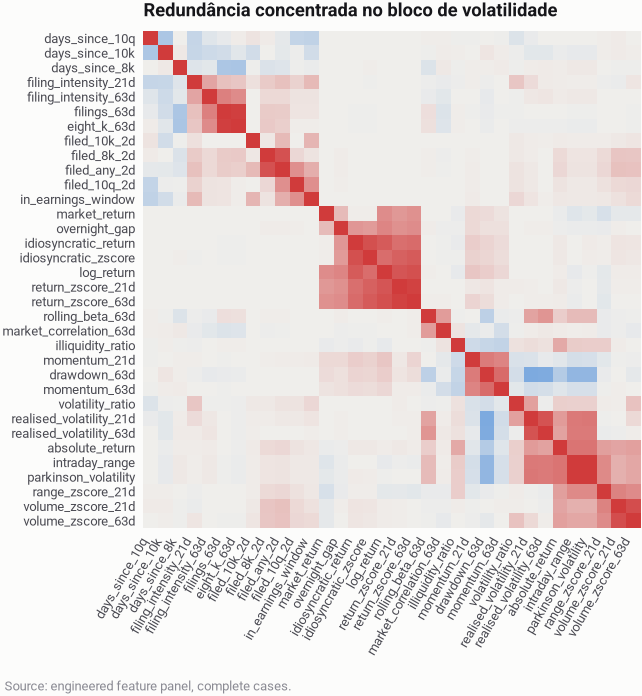

In [14]:
# Correlation structure among the market and disclosure features

core_features = MARKET_FEATURES + RELATIVE_FEATURES + DISCLOSURE_FEATURES
feature_matrix = model_df[core_features].replace([np.inf, -np.inf], np.nan).dropna()

correlation = feature_matrix.corr()

# Order by hierarchical similarity so blocks of redundancy become visible.
from scipy.cluster.hierarchy import leaves_list, linkage
from scipy.spatial.distance import squareform

distance = (1 - correlation.abs()).to_numpy(copy=True)
np.fill_diagonal(distance, 0)
order = leaves_list(linkage(squareform(distance, checks=False), method="average"))
ordered = correlation.iloc[order, order]

fig, ax = plt.subplots(figsize=(6.30, 5.38))
ax.imshow(ordered.to_numpy(), cmap=viz.diverging_cmap(), vmin=-1, vmax=1)
ax.set_xticks(range(len(ordered)), ordered.columns, rotation=60, ha="right", fontsize=8)
ax.set_yticks(range(len(ordered)), ordered.index, fontsize=8)
ax.grid(visible=False)
viz.hide_axis_ticks(ax, "both")
for spine in ax.spines.values():
    spine.set_visible(False)

viz.title(ax, "Redundância concentrada no bloco de volatilidade")
viz.source_note(fig, "Source: engineered feature panel, complete cases.")

viz.save_fig(fig, "12_feature_correlation")
plt.show()

In [15]:
# Variance inflation factors on the standardised feature matrix

scaled = StandardScaler().fit_transform(feature_matrix)
vif_df = pd.DataFrame({
    "feature": feature_matrix.columns,
    "vif": [variance_inflation_factor(scaled, position)
            for position in range(scaled.shape[1])],
}).sort_values("vif", ascending=False)

vif_df["severity"] = pd.cut(
    vif_df["vif"], [0, 5, 10, np.inf],
    labels=["acceptable", "moderate", "severe"],
)

vif_df.head(15).round(2)

,feature,vif,severity
23,filed_10q_2d,inf,severe
22,filed_8k_2d,inf,severe
24,filed_10k_2d,inf,severe
25,filed_any_2d,inf,severe
3,parkinson_volatility,853.1700,severe
2,intraday_range,852.1100,severe
28,filings_63d,35.4200,severe
29,eight_k_63d,32.0600,severe
6,return_zscore_63d,29.2100,severe
0,log_return,27.2600,severe


In [16]:
# Dropping the features that are near-duplicates of something already present

# Each removal has a stated reason, and the target is a maximum VIF below 10, the
# conventional threshold above which a feature is mostly explained by the others.
REDUNDANT_FEATURES = [
    "parkinson_volatility",     # a monotone transform of intraday_range
    "realised_volatility_63d",  # implied by realised_volatility_21d and volatility_ratio
    "absolute_return",          # a deterministic function of log_return
    "filings_63d",              # superseded by filing_intensity_63d
    "filed_any_2d",             # the sum of the three per-form counters
    "idiosyncratic_return",     # the same quantity as its z-score, unscaled
    "return_zscore_63d",        # the 21-day window carries the deviation signal
]

MODEL_FEATURES = [
    feature for feature in FEATURE_COLUMNS if feature not in REDUNDANT_FEATURES
]
MODEL_FEATURES_CORE = [
    feature for feature in MODEL_FEATURES if feature not in FUNDAMENTAL_FEATURES
]

reduced = model_df[MODEL_FEATURES_CORE].replace([np.inf, -np.inf], np.nan).dropna()
reduced_scaled = StandardScaler().fit_transform(reduced)
reduced_vif = pd.Series(
    [variance_inflation_factor(reduced_scaled, position)
     for position in range(reduced_scaled.shape[1])],
    index=reduced.columns,
).sort_values(ascending=False)

print(f"Features retained: {len(MODEL_FEATURES)} "
      f"({len(MODEL_FEATURES_CORE)} without the fundamental block)")
print(f"Worst VIF before pruning: {vif_df['vif'].max():.1f}")
print(f"Worst VIF after pruning:  {reduced_vif.max():.1f}")

reduced_vif.head(8).round(2)

Features retained: 36 (27 without the fundamental block)
Worst VIF before pruning: inf
Worst VIF after pruning:  7.8


return_zscore_21d         7.8300
idiosyncratic_zscore      7.2300
volume_zscore_63d         7.1100
volume_zscore_21d         7.0400
drawdown_63d              6.3800
log_return                5.7300
realised_volatility_21d   5.2300
intraday_range            4.8100
dtype: float64

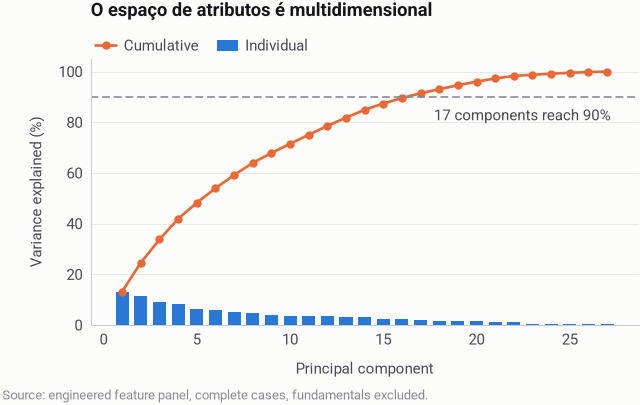

In [17]:
# How many dimensions actually carry the variance?

pca = PCA().fit(reduced_scaled)
explained = np.cumsum(pca.explained_variance_ratio_)
components_for_90 = int(np.searchsorted(explained, 0.90) + 1)

fig, ax = plt.subplots(figsize=(5.89, 2.88))
positions = np.arange(1, len(explained) + 1)
ax.bar(positions, 100 * pca.explained_variance_ratio_, color=viz.CATEGORICAL[0],
       label="Individual", width=0.7)
ax.plot(positions, 100 * explained, color=viz.CATEGORICAL[1], marker="o", markersize=4,
        label="Cumulative")
ax.axhline(90, color=viz.INK_MUTED, linewidth=1.0, linestyle=(0, (4, 3)))
ax.annotate(
    f"{components_for_90} components reach 90%",
    xy=(components_for_90, 90), xytext=(8, -14), textcoords="offset points",
    fontsize=9, color=viz.INK_SECONDARY,
)

ax.set_xlabel("Principal component")
ax.set_ylabel("Variance explained (%)")
viz.legend_above(ax, ncols=2)
viz.title(ax, "O espaço de atributos é multidimensional", legend_rows=1)
viz.source_note(fig, "Source: engineered feature panel, complete cases, fundamentals excluded.")

viz.save_fig(fig, "13_pca_scree")
plt.show()

No single component dominates, and reaching 90% of the variance takes well over half the
features. That is the desired outcome: the blocks are measuring genuinely different things
rather than restating one underlying quantity, which is what gives a multivariate detector
something to work with that a univariate rule cannot see.

Dimensionality reduction is therefore *not* applied before modelling. Projecting onto
principal components would make each anomaly score a mixture of all the original features,
and the project needs to be able to say **why** a day was flagged: the classification of
anomaly types and the executive briefings both depend on attributing a score back to
volume, price or disclosure behaviour.

---

## 9. Persisting the panel and its dictionary

The dataset is written together with a machine-readable feature dictionary. Every column
records which block it belongs to, what it measures and which lookback it uses, the
document the API's feature schema and the business case's variable table are both
generated from.

In [18]:
# Feature dictionary

FEATURE_DESCRIPTIONS = {
    "log_return": ("market", "Daily log return", "1 day"),
    "intraday_range": ("market", "High-low range scaled by close", "1 day"),
    "overnight_gap": ("market", "Log change from previous close to open", "1 day"),
    "return_zscore_21d": ("market", "Return standardised on the previous 21 sessions", "21 days"),
    "return_zscore_63d": ("market", "Return standardised on the previous 63 sessions", "63 days"),
    "volume_zscore_21d": ("market", "Log volume standardised on the previous 21 sessions", "21 days"),
    "volume_zscore_63d": ("market", "Log volume standardised on the previous 63 sessions", "63 days"),
    "range_zscore_21d": ("market", "Intraday range standardised on the previous 21 sessions", "21 days"),
    "realised_volatility_21d": ("market", "Standard deviation of returns", "21 days"),
    "volatility_ratio": ("market", "Short-term over long-term realised volatility", "21/63 days"),
    "drawdown_63d": ("market", "Distance below the rolling maximum close", "63 days"),
    "momentum_21d": ("market", "Cumulative log return", "21 days"),
    "momentum_63d": ("market", "Cumulative log return", "63 days"),
    "illiquidity_ratio": ("market", "Amihud illiquidity over its own trailing mean", "252 days"),
    "market_return": ("market-relative", "Equally weighted return of the other nine issuers", "1 day"),
    "rolling_beta_63d": ("market-relative", "Sensitivity to the peer return", "63 days"),
    "idiosyncratic_return": ("market-relative", "Return net of the market component", "1 day"),
    "idiosyncratic_zscore": ("market-relative", "Idiosyncratic return in units of its own volatility", "63 days"),
    "market_correlation_63d": ("market-relative", "Correlation with the peer return", "63 days"),
    "filed_8k_2d": ("disclosure", "Current reports filed today or the previous session", "2 days"),
    "filed_10q_2d": ("disclosure", "Quarterly reports filed today or the previous session", "2 days"),
    "filed_10k_2d": ("disclosure", "Annual reports filed today or the previous session", "2 days"),
    "filing_intensity_21d": ("disclosure", "Recent filing rate over the issuer's own baseline", "21/252 days"),
    "filing_intensity_63d": ("disclosure", "Recent filing rate over the issuer's own baseline", "63/252 days"),
    "eight_k_63d": ("disclosure", "Count of current reports", "63 days"),
    "days_since_8k": ("disclosure", "Sessions since the last current report", "expanding"),
    "days_since_10q": ("disclosure", "Sessions since the last quarterly report", "expanding"),
    "days_since_10k": ("disclosure", "Sessions since the last annual report", "expanding"),
    "in_earnings_window": ("disclosure", "Within five sessions of a periodic report", "5 days"),
    "net_margin": ("fundamentals", "Net income over revenue, as last reported", "point-in-time"),
    "operating_margin": ("fundamentals", "Operating income over revenue, as last reported", "point-in-time"),
    "rd_intensity": ("fundamentals", "R&D expense over revenue, as last reported", "point-in-time"),
    "revenue_growth_yoy": ("fundamentals", "Year-over-year revenue growth", "point-in-time"),
    "net_income_growth_yoy": ("fundamentals", "Year-over-year net income growth", "point-in-time"),
    "leverage": ("fundamentals", "Liabilities over assets", "point-in-time"),
    "cash_to_assets": ("fundamentals", "Cash over assets", "point-in-time"),
    "equity_to_assets": ("fundamentals", "Equity over assets", "point-in-time"),
    "asset_growth_yoy": ("fundamentals", "Year-over-year asset growth", "point-in-time"),
}

dictionary_df = pd.DataFrame([
    {
        "feature": feature,
        "block": FEATURE_DESCRIPTIONS[feature][0],
        "description": FEATURE_DESCRIPTIONS[feature][1],
        "lookback": FEATURE_DESCRIPTIONS[feature][2],
        "in_core_set": feature in MODEL_FEATURES_CORE,
        "missing_pct": round(100 * model_df[feature].isna().mean(), 2),
    }
    for feature in MODEL_FEATURES
])

dictionary_df

,feature,block,description,lookback,in_core_set,missing_pct
0,log_return,market,Daily log return,1 day,True,0.0100
1,intraday_range,market,High-low range scaled by close,1 day,True,0.0000
2,overnight_gap,market,Log change from previous close to open,1 day,True,0.0100
3,return_zscore_21d,market,Return standardised on the previous 21 sessions,21 days,True,0.1600
4,volume_zscore_21d,market,Log volume standardised on the previous 21 ses...,21 days,True,0.1500
5,volume_zscore_63d,market,Log volume standardised on the previous 63 ses...,63 days,True,0.4600
6,range_zscore_21d,market,Intraday range standardised on the previous 21...,21 days,True,0.1500
7,realised_volatility_21d,market,Standard deviation of returns,21 days,True,0.1500
8,volatility_ratio,market,Short-term over long-term realised volatility,21/63 days,True,0.4400
9,drawdown_63d,market,Distance below the rolling maximum close,63 days,True,0.2800


In [19]:
# Writing the panel and its metadata

IDENTIFIER_COLUMNS = [
    "ticker", "date", "close", "volume", "has_fundamentals",
    "fundamentals_as_of", "fundamentals_age_days",
]

output_df = model_df[IDENTIFIER_COLUMNS + MODEL_FEATURES].copy()
output_df = output_df.replace([np.inf, -np.inf], np.nan)

# Drop the warm-up period: rows before the longest rolling window has any history.
warm_up_mask = output_df[
    ["return_zscore_21d", "realised_volatility_21d", "volatility_ratio"]
].isna().any(axis=1)
output_df = output_df[~warm_up_mask].reset_index(drop=True)

output_df.to_csv(DATA_DIR / "model_ready_dataset.csv", index=False)
dictionary_df.to_csv(DATA_DIR / "feature_dictionary.csv", index=False)

print(f"model_ready_dataset.csv  {output_df.shape[0]:,} rows x {output_df.shape[1]} columns")
print(f"Window: {output_df['date'].min():%Y-%m-%d} to {output_df['date'].max():%Y-%m-%d}")
print(f"Complete cases on the core feature set: "
      f"{output_df[MODEL_FEATURES_CORE].notna().all(axis=1).mean():.1%}")
print(f"Complete cases including fundamentals:  "
      f"{output_df[MODEL_FEATURES].notna().all(axis=1).mean():.1%}")

output_df.head()

model_ready_dataset.csv  67,612 rows x 43 columns
Window: 1994-02-14 to 2026-05-21
Complete cases on the core feature set: 93.9%
Complete cases including fundamentals:  25.6%


,ticker,date,close,volume,has_fundamentals,fundamentals_as_of,fundamentals_age_days,log_return,intraday_range,overnight_gap,return_zscore_21d,volume_zscore_21d,volume_zscore_63d,range_zscore_21d,realised_volatility_21d,volatility_ratio,drawdown_63d,momentum_21d,momentum_63d,illiquidity_ratio,market_return,rolling_beta_63d,idiosyncratic_zscore,market_correlation_63d,filed_8k_2d,filed_10q_2d,filed_10k_2d,filing_intensity_21d,filing_intensity_63d,eight_k_63d,days_since_8k,days_since_10q,days_since_10k,in_earnings_window,net_margin,operating_margin,rd_intensity,revenue_growth_yoy,net_income_growth_yoy,leverage,cash_to_assets,equity_to_assets,asset_growth_yoy
0,AAPL,1994-02-14,0.2771,"292,680,865.0000",False,NaT,NaN,0.0000,0.0337,0.0000,-0.2466,-0.0744,NaN,-0.4726,0.0365,0.9779,0.0000,0.1767,NaN,NaN,0.0112,NaN,NaN,0.1990,0.0000,0.0000,0.0000,NaN,NaN,0.0000,NaN,13.0000,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AAPL,1994-02-15,0.2781,"154,684,097.0000",False,NaT,NaN,0.0034,0.0346,-0.0064,-0.1377,-1.1613,-1.3976,-0.3893,0.0359,0.9783,0.0000,0.2009,NaN,NaN,0.0186,0.4904,NaN,0.1921,0.0000,0.0000,0.0000,NaN,NaN,0.0000,NaN,14.0000,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AAPL,1994-02-16,0.2753,"145,446,018.0000",False,NaT,NaN,-0.0098,0.0208,0.0107,-0.5402,-1.2431,-1.4464,-1.2100,0.0348,0.9613,-0.0098,0.2249,NaN,NaN,0.0084,0.4652,NaN,0.1863,0.0000,0.0000,0.0000,NaN,NaN,0.0000,NaN,15.0000,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AAPL,1994-02-17,0.2771,"173,013,382.0000",False,NaT,NaN,0.0064,0.0445,0.0129,-0.1230,-0.8446,-1.0711,0.3261,0.0347,0.9725,-0.0034,0.2353,NaN,NaN,-0.0030,0.4518,NaN,0.1857,0.0000,0.0000,0.0000,NaN,NaN,0.0000,NaN,16.0000,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AAPL,1994-02-18,0.2714,"177,685,749.0000",False,NaT,NaN,-0.0207,0.0209,-0.0140,-0.9207,-0.7388,-0.9904,-1.1312,0.0352,0.9957,-0.0238,0.1930,NaN,NaN,0.0044,0.4491,NaN,0.1825,0.0000,0.0000,0.0000,NaN,NaN,0.0000,NaN,17.0000,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---

## Conclusion

The panel now carries features that are, by construction, comparable across issuers,
across price levels and across regulatory regimes, and that are verified not to depend on
information unavailable at the time.

| | Previous version | This version |
|---|---|---|
| Observations | 27,730 | see the summary above |
| Window | 2015-2026 | 1994-2026 |
| Fundamentals join | period end date | filing date |
| Look-ahead in the fundamentals | median ~6 weeks | none, tested |
| Restatements | latest value used retroactively | first published value only |
| Deviation scoring | window includes the scored day | trailing window only |
| Market-relative block | absent | beta, idiosyncratic return, correlation |
| Disclosure window | filing day | filing day and the next session |
| Redundancy control | none | correlation, VIF, explicit pruning |
| Documentation | none | machine-readable feature dictionary |

Two decisions are deliberately left to be settled by measurement rather than argument in
the next notebook: whether the fundamental block earns its cost in lost history, and which
detector family handles this feature space best. Both are questions the data can answer.